Data loaded successfully.
Full rows after cleaning: 23578
Valid rows: 22039
Baseline pump curve coefficients:
a1 = 33.400000, a2 = -0.033025, a3 = -0.000000

Running window size = 10 samples (stride = 10)
[Learning complete] Clean normals=20, excluded suspects=9, t1=0.0250, t2=0.0600

Running window size = 15 samples (stride = 15)
[Learning complete] Clean normals=20, excluded suspects=1, t1=0.0250, t2=0.0600

Running window size = 25 samples (stride = 25)
[Learning complete] Clean normals=20, excluded suspects=4, t1=0.0250, t2=0.0600

Running window size = 35 samples (stride = 35)
[Learning complete] Clean normals=20, excluded suspects=3, t1=0.0250, t2=0.0600

Running window size = 50 samples (stride = 50)
[Learning complete] Clean normals=20, excluded suspects=0, t1=0.0250, t2=0.0600

Running window size = 75 samples (stride = 75)
[Learning complete] Clean normals=17, excluded suspects=20, t1=0.0250, t2=0.0600

Running window size = 100 samples (stride = 100)
[Learning complete] Clea

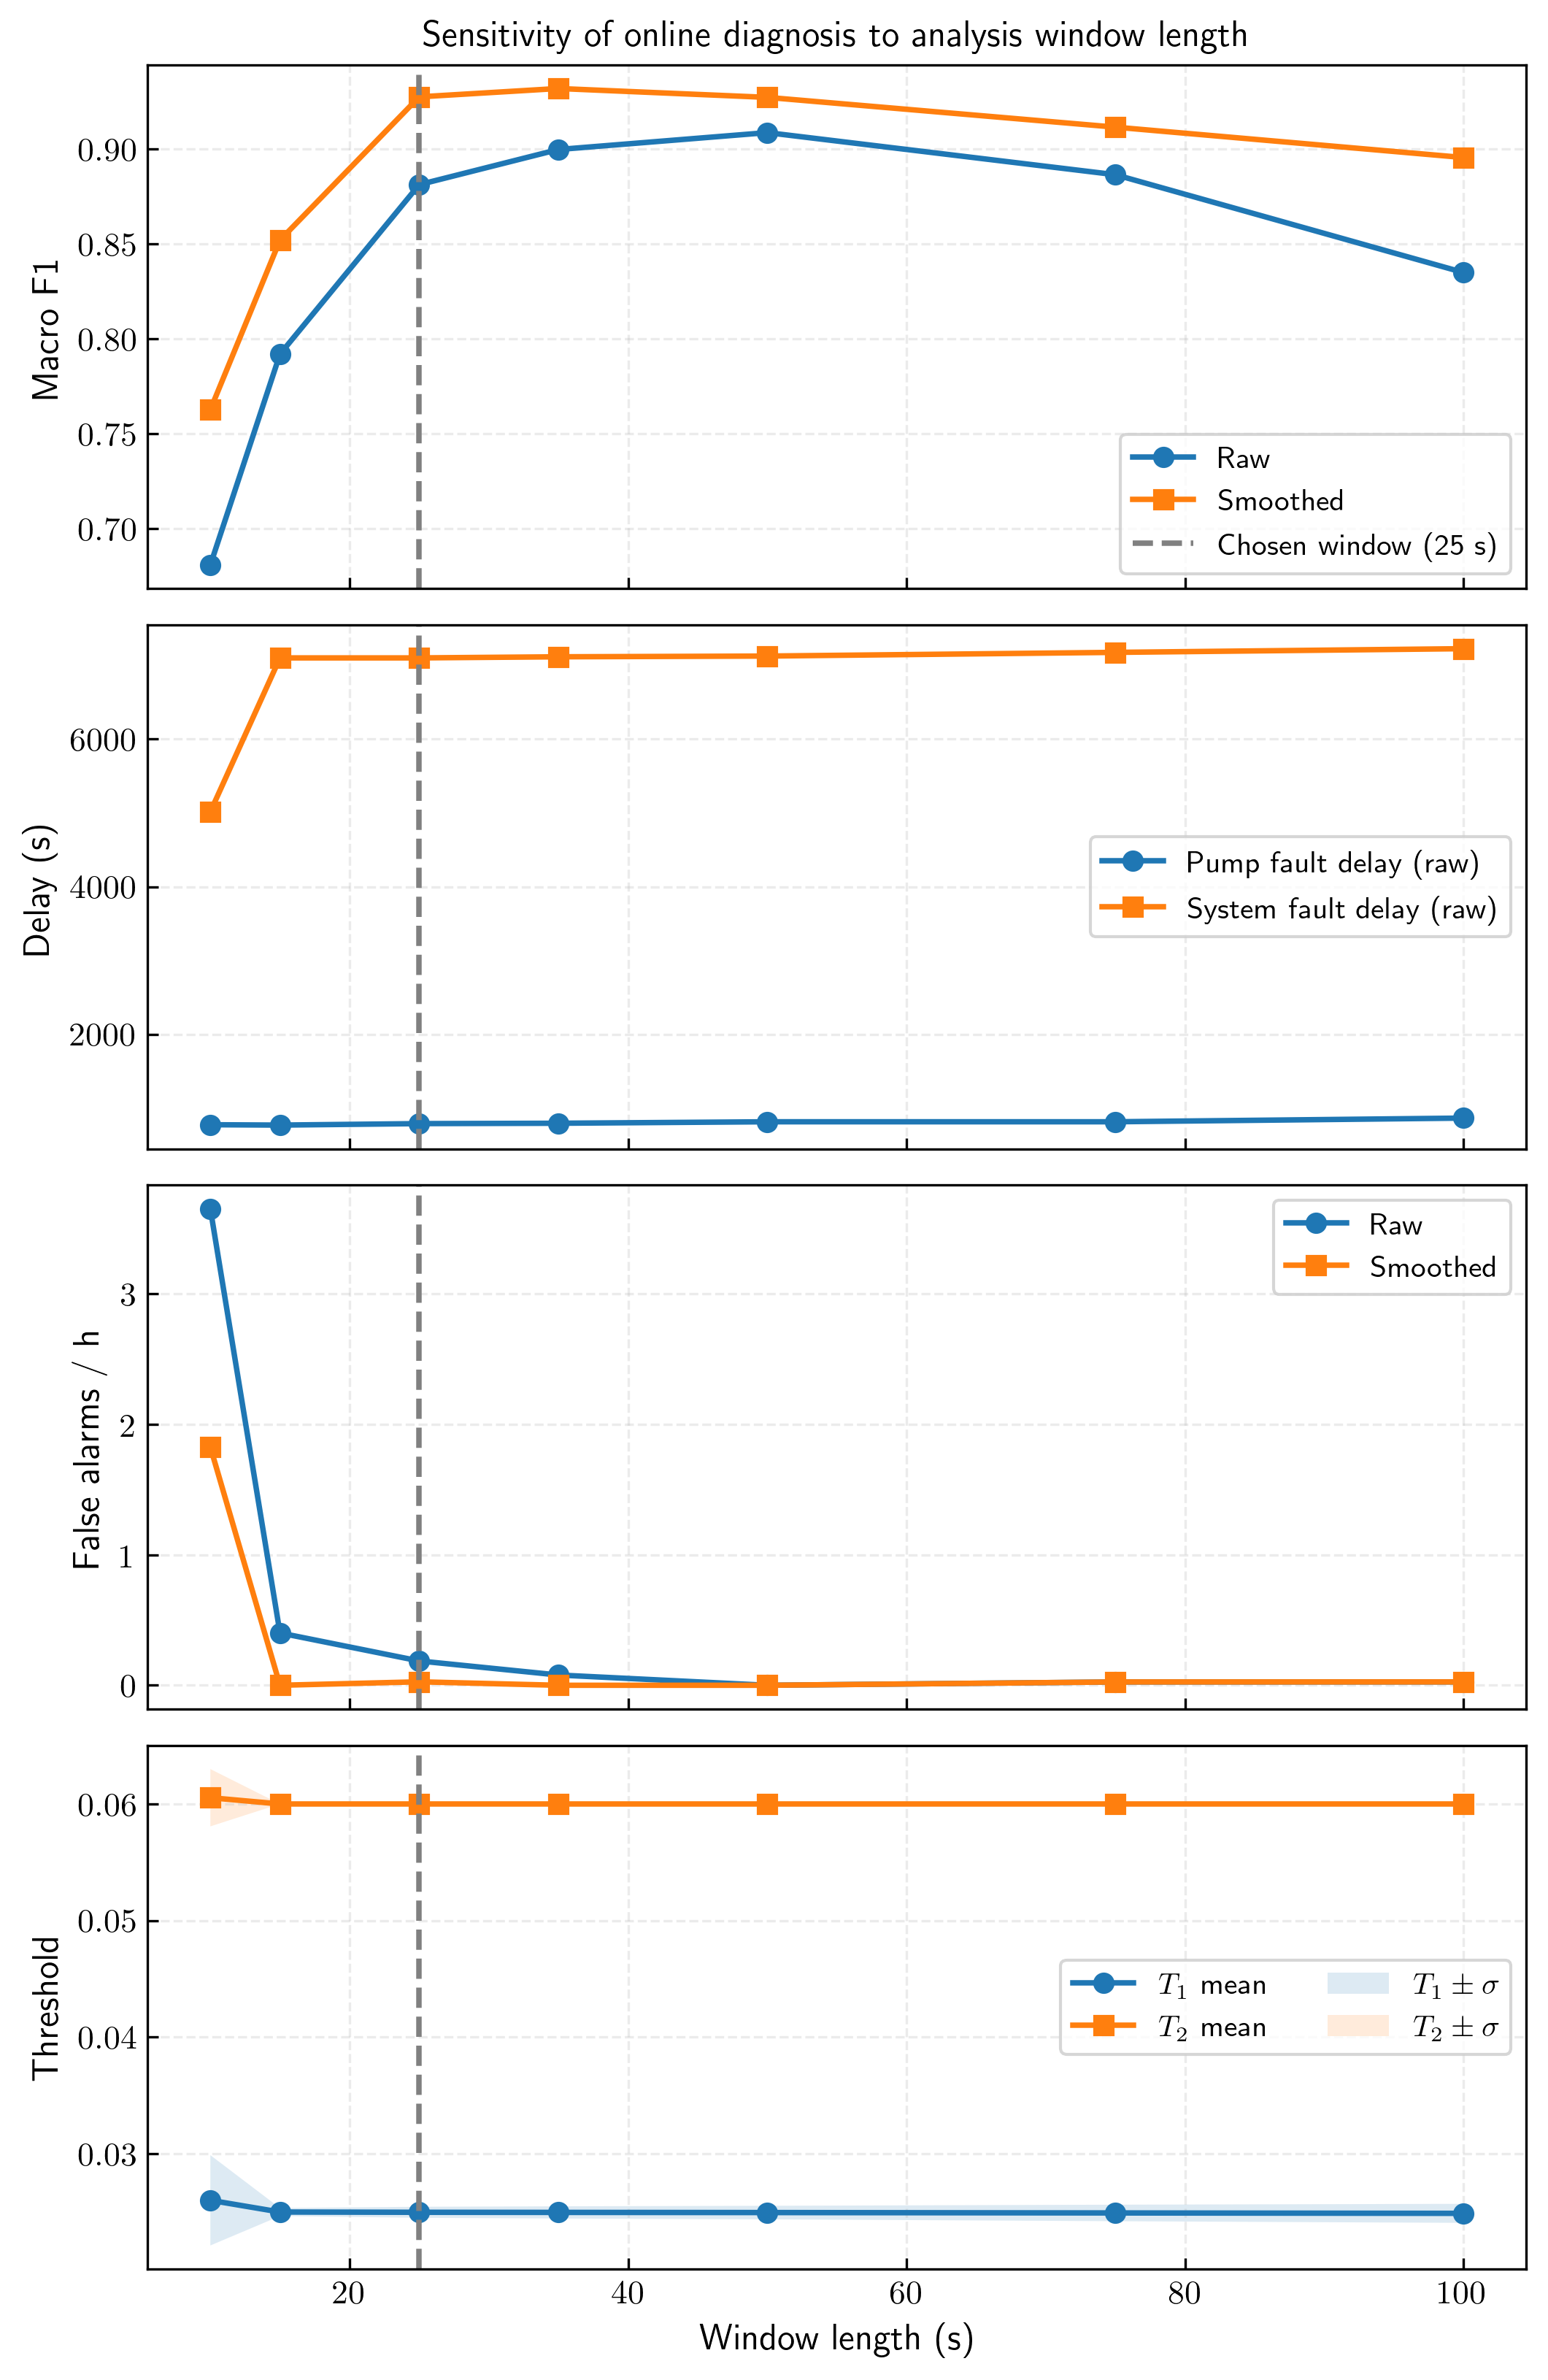

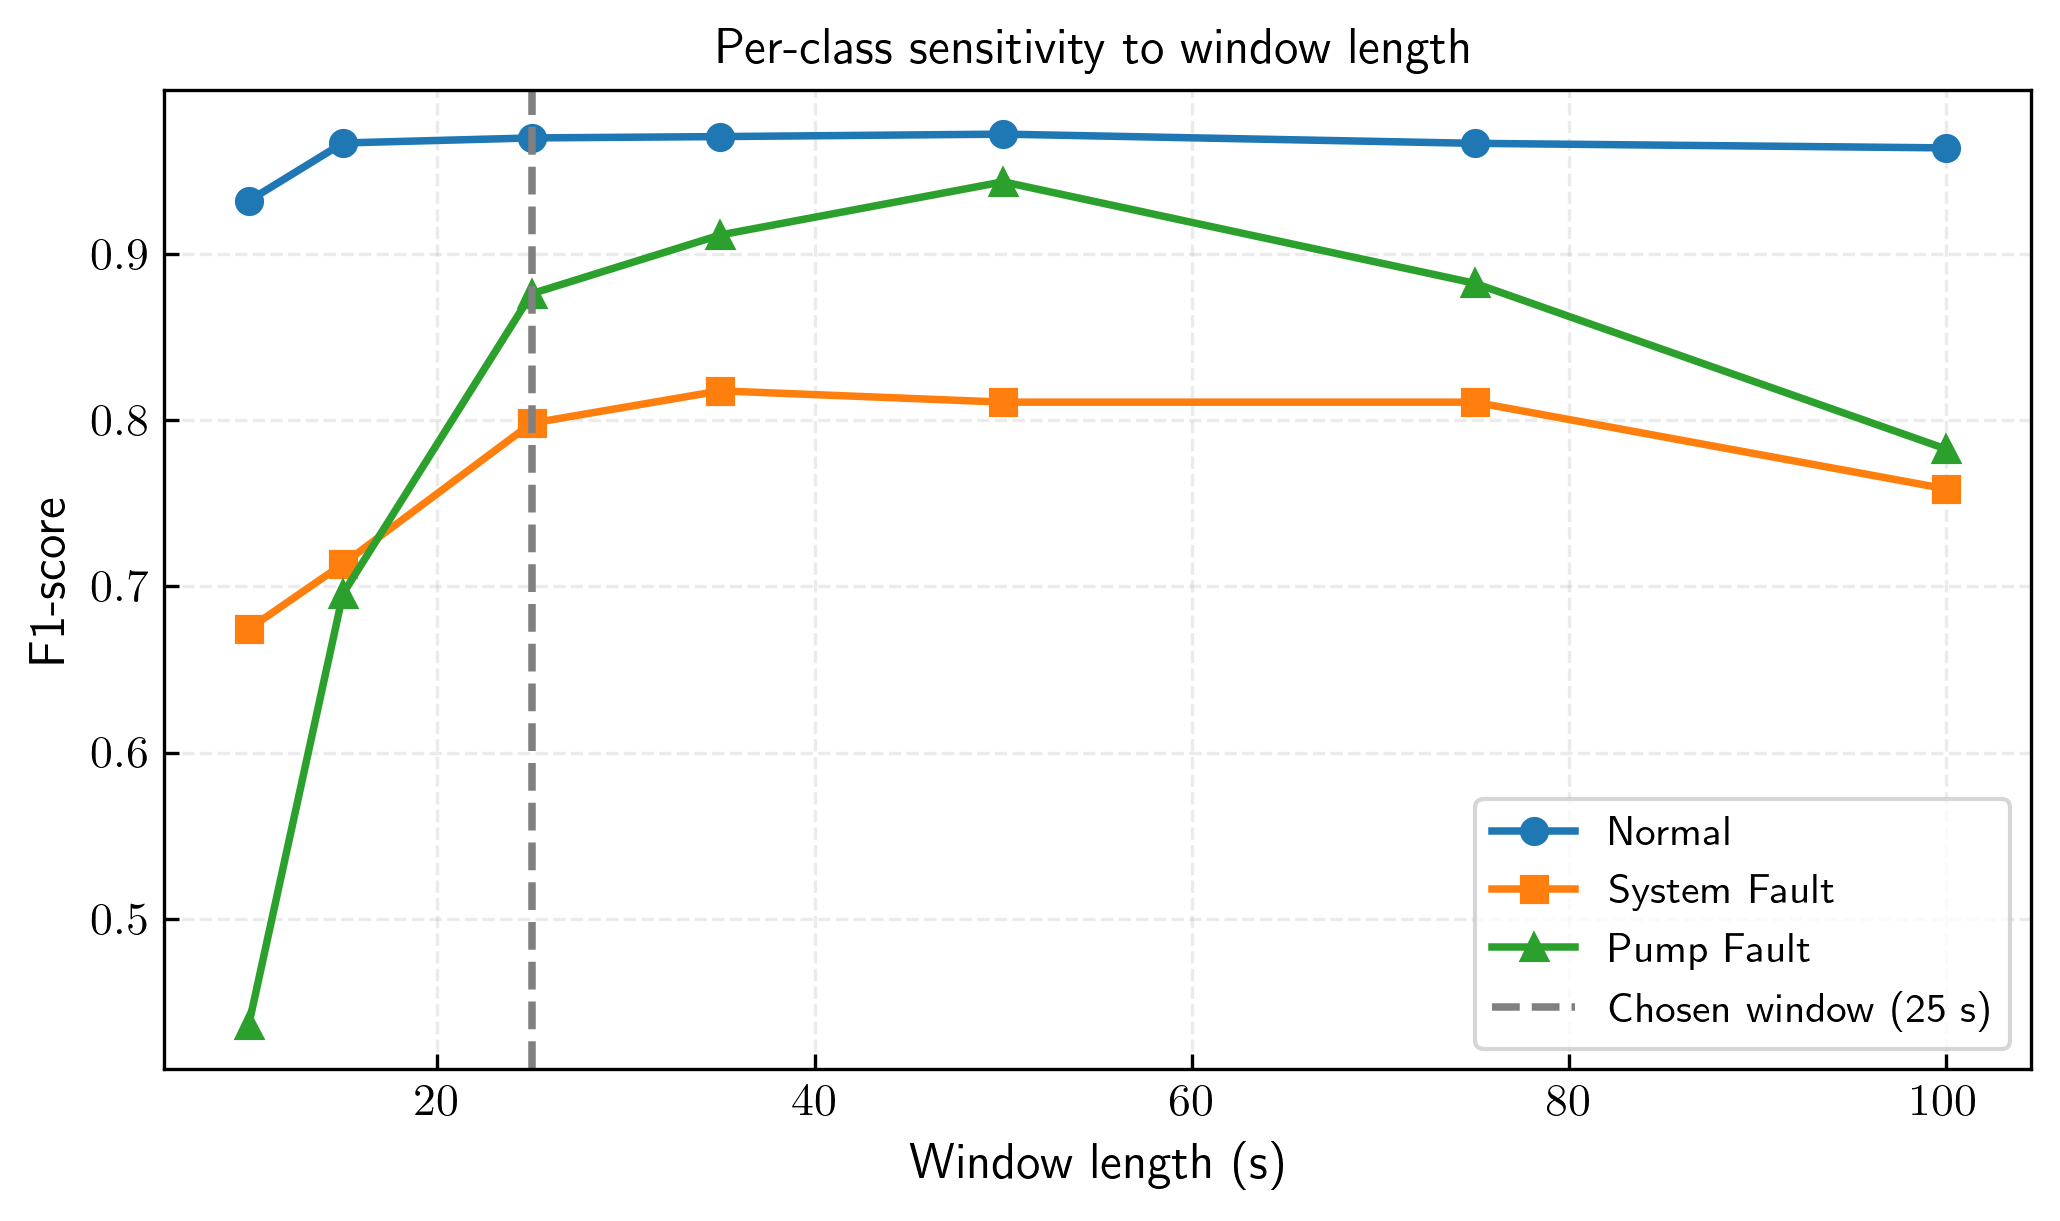


All outputs saved to:
C:\Users\eshkofti\Myfiles\Decorum\Manuscript\Final Codes\GitHub codes\Sensitivity Analysis\Window size


In [ ]:
# Window-length sensitivity study for the tangent-residual detector
#
# This script evaluates how the online tangent-residual detector behaves when
# the analysis window length changes. The detector itself is kept unchanged; the
# experiment only varies the window size and then records the resulting
# classification metrics, detection delays, false-alarm rate, and threshold
# stability.
#
# Notes:
#   - The learning phase is set to 6 hours to match the manuscript description.
#   - The data resolution is 1 second, so the window length in samples is also
#     the window length in seconds.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import deque
import time

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

# ============================================================
# 0) Plot style
# ============================================================
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "lines.linewidth": 1.8,
})
plt.rcParams["text.usetex"] = True  


# ============================================================
# 1) Paths and experiment settings
# ============================================================

# Input data file
#excel_path = Path("data") / "pump_system_faultsimualtion.xlsx"

# Output folder
#output_dir = Path("results") / "window_size"
#output_dir.mkdir(parents=True, exist_ok=True)

excel_path = Path(
    r"C:\Users\eshkofti\Myfiles\Decorum\Manuscript\Final Codes\diagnostic-statistical\simulator\pump_system_faultsimualtion.xlsx"
)

# ---------- Output folder ----------
output_dir = Path(
    r"C:\Users\eshkofti\Myfiles\Decorum\Manuscript\Final Codes\GitHub codes\Sensitivity Analysis\Window size"
)
output_dir.mkdir(parents=True, exist_ok=True)

# Window sizes to test
window_sizes = [10, 15, 25, 35, 50, 75, 100]

# Stride mode
# "nonoverlap" -> stride = window_size
# "overlap"    -> stride = fixed number of samples (e.g., 5)
stride_mode = "nonoverlap"
overlap_stride = 5

# Ground-truth intervals
pump_fault_interval   = (12000.0, 21000.0)
system_fault_interval = (86400.0 + 40000.0, 86400.0 + 61600.0)

# Also evaluate the smoothed state sequence
apply_state_smoothing = True
smoothing_window = 3

# Reproducibility
random_seed = 13
np.random.seed(random_seed)


# ============================================================
# 2) Detector settings
#    The detector logic is unchanged. The learning period is kept at 6 hours
#    to match the manuscript text.
# ============================================================

# Learning / adaptation knobs
learning_max_time_s = 6 * 60 * 60      # 6 hours (paper-consistent)
learning_min_normal_cycles = 20
learning_outlier_guard = 3.0

adaptation_window = 1000
adaptation_interval = 50

# Provisional thresholds
provisional_t1_default = 0.020
provisional_t2_default = 0.060

# Threshold trimming / floors
trim_top_quantile = 0.85
t1_min_floor = 0.025
t2_min_floor = 0.060

# Variance gate near T1
variance_gate_relative_margin = 0.20
std_z_upper = 2.5
std_z_lower = -0.5

# Valid-segment requirements
full_speed_hz = 49.5
min_flow_m3h = 0.1
frequency_stability_window = 5
max_frequency_std = 0.5

# Minimum number of samples in an online window
# This is controlled by the window-size list in the sensitivity study.
min_segment_length_to_process = 10

# Known system curve constants
friction_coefficient = 0.0006
nominal_frequency_hz = 50.0

eps = 1e-9


# ============================================================
# 3) Data preparation
# ============================================================

def load_and_prepare_data(excel_path: Path):
    """
    Load the Excel dataset and create the Pump 1 working dataframe.

    Returns
    -------
    df : full dataframe
    p1 : Pump 1 reduced dataframe with columns:
         ['t_s', 'Q1', 'H1', 'f1', 'valid']
    """
    df = pd.read_excel(excel_path)

    # Make sure the timestamp column is in datetime format.
    if not np.issubdtype(df["Timestamp"].dtype, np.datetime64):
        df["Timestamp"] = pd.to_datetime(df["Timestamp"])

    # Use seconds from the beginning of the experiment.
    t0 = df["Timestamp"].min()
    df["t_s"] = (df["Timestamp"] - t0).dt.total_seconds().astype(float)

    # Keep the variables needed for Pump 1.
    p1 = df[["t_s", "Pump1_Flow_m3h", "Pump1_Head_m", "Pump1_Freq_Hz"]].copy()
    p1.columns = ["t_s", "Q1", "H1", "f1"]

    # Keep physically meaningful samples.
    p1 = p1[(p1["Q1"] > 0) & (p1["H1"] > 0) & (p1["f1"] > 0)].copy()

    # Mark samples that correspond to stable, full-speed operation.
    fullspeed = p1["f1"] >= full_speed_hz
    positive_flow = p1["Q1"] > min_flow_m3h
    stable_operation = (
        p1["f1"].rolling(frequency_stability_window, center=True).std() < max_frequency_std
    )

    p1["valid"] = (fullspeed & positive_flow & stable_operation.fillna(False))

    return df, p1


# ============================================================
# 4) Baseline pump-curve fit
# ============================================================

def fit_baseline_curve(p1: pd.DataFrame, baseline_end_s: float = 12000.0):
    """
    Fit the nominal Pump 1 H-Q quadratic curve:
        H ≈ a1 + a2*Q + a3*Q^2

    Returns
    -------
    a1, a2, a3
    """
    baseline = p1[(p1["t_s"] < baseline_end_s) & p1["valid"]].copy()

    if len(baseline) > 10:
        Xp = np.vstack([
            np.ones(len(baseline)),
            baseline["Q1"].values,
            baseline["Q1"].values ** 2
        ]).T
        y = baseline["H1"].values
        a_hat, _, _, _ = np.linalg.lstsq(Xp, y, rcond=None)
        a1, a2, a3 = a_hat
    else:
        a1, a2, a3 = 10.0, -0.1, -0.001

    return float(a1), float(a2), float(a3)


# ============================================================
# 5) Helper functions
# ============================================================

def robust_boxcar(x, w=11):
    """
    Median filter with odd window size.
    """
    x = np.asarray(x, dtype=float)
    if w <= 1:
        return x.copy()
    if w % 2 == 0:
        w += 1

    result = np.zeros_like(x)
    half = w // 2
    n = len(x)

    for i in range(n):
        s = max(0, i - half)
        e = min(n, i + half + 1)
        result[i] = np.median(x[s:e])

    return result


def enhanced_central_diff(x, dt=1.0):
    """
    Central difference with edge handling + mild smoothing.
    """
    x = np.asarray(x, dtype=float)
    n = len(x)
    d = np.zeros_like(x, dtype=float)

    if n == 1:
        return d
    if n == 2:
        d[:] = (x[1] - x[0]) / max(dt, eps)
        return d

    d[1:-1] = (x[2:] - x[:-2]) / (2.0 * max(dt, eps))
    d[0] = (x[1] - x[0]) / max(dt, eps)
    d[-1] = (x[-1] - x[-2]) / max(dt, eps)

    d = robust_boxcar(d, 5)
    return d


def mad(x):
    return stats.median_abs_deviation(x, scale="normal")


def robust_z(x, ref_values):
    """
    Robust z-score of scalar x relative to reference array.
    """
    ref = np.asarray(ref_values, dtype=float)
    if ref.size < 6:
        return 0.0
    m = np.median(ref)
    s = mad(ref) + eps
    return (x - m) / s


def overlap_ratio(a0, a1, b0, b1):
    """
    Fraction of interval [a0, a1] that overlaps [b0, b1].
    """
    if a1 <= a0:
        return 0.0
    left = max(a0, b0)
    right = min(a1, b1)
    return max(0.0, right - left) / (a1 - a0)


def confusion_df(y_true, y_pred, labels):
    """
    Simple confusion matrix as DataFrame.
    """
    cm = pd.DataFrame(0, index=labels, columns=labels, dtype=int)
    for t, p in zip(y_true, y_pred):
        if t in labels and p in labels:
            cm.loc[t, p] += 1
    return cm


def compute_prf_from_cm(cm, labels):
    """
    Precision, recall, F1 from confusion matrix.
    Returns a dictionary.
    """
    out = {}
    f1_list = []
    p_list = []
    r_list = []

    for label in labels:
        tp = cm.loc[label, label]
        fp = cm[label].sum() - tp
        fn = cm.loc[label].sum() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        out[f"{label}_precision"] = precision
        out[f"{label}_recall"] = recall
        out[f"{label}_f1"] = f1

        p_list.append(precision)
        r_list.append(recall)
        f1_list.append(f1)

    out["precision_macro"] = float(np.mean(p_list))
    out["recall_macro"] = float(np.mean(r_list))
    out["f1_macro"] = float(np.mean(f1_list))
    out["accuracy"] = cm.values.trace() / max(cm.values.sum(), 1)

    return out


# ============================================================
# 6) Fixed-size online windows
# ============================================================

def build_fixed_windows_from_valid_runs(p1_valid: pd.DataFrame, window_size: int, stride: int):
    """
    Build fixed-size windows from the samples that passed the validity checks.

    Important:
    We only use already-valid samples. Since p1_valid is the filtered stream,
    the windows represent the online analysis windows after your validity
    screening (near full speed, stable operation, positive flow).

    Parameters
    ----------
    p1_valid : filtered valid dataframe
    window_size : number of samples in each window
    stride : shift between consecutive windows

    Returns
    -------
    windows : list of window DataFrames
    """
    windows = []
    n = len(p1_valid)

    for start in range(0, n - window_size + 1, stride):
        end = start + window_size
        seg = p1_valid.iloc[start:end].copy()
        if len(seg) == window_size:
            windows.append(seg)

    return windows


# ============================================================
# 7) Detector class
# ============================================================

class EnhancedFaultDetector:
    """
    Online tangent-residual detector with:
      - contamination-safe learning,
      - trimmed threshold estimation,
      - variance gate near T1,
      - adaptive threshold updates.
    """

    def __init__(self, full_df, a1, a2, a3):
        self.df = full_df
        self.a1 = a1
        self.a2 = a2
        self.a3 = a3

        self.learning_phase = True

        self.clean_normal_iw = []
        self.clean_normal_std_sum = []

        self.provisional_t1 = provisional_t1_default
        self.provisional_t2 = provisional_t2_default

        self.t1_threshold = np.nan
        self.t2_threshold = np.nan

        self.recent_normal_iw = deque(maxlen=adaptation_window)
        self.recent_normal_std_sum = deque(maxlen=adaptation_window)

        self.cycle_count = 0
        self.consecutive_faults = 0
        self.current_state = "Normal"

        self.results = []
        self.suspect_excluded = 0

    def _trimmed_thresholds(self, iw_data):
        x = np.asarray(iw_data, dtype=float)

        if x.size < 8:
            t1 = max(t1_min_floor, float(self.provisional_t1))
            t2 = max(t2_min_floor, float(self.provisional_t2))
            if t2 <= t1:
                t2 = max(t1 * 1.5, t1 + 0.01)
            return float(t1), float(t2)

        x_sorted = np.sort(x)
        cut = np.quantile(x_sorted, trim_top_quantile)
        trimmed = x_sorted[x_sorted <= cut]
        if trimmed.size < 5:
            trimmed = x_sorted

        med = np.median(trimmed)
        m = mad(trimmed)

        t1_threshold = med + 1.5 * m
        t2_threshold = med + 3.0 * m

        if t2_threshold <= t1_threshold:
            t2_threshold = max(t1_threshold * 1.5, t1_threshold + 0.01)

        t1_threshold = max(t1_min_floor, t1_threshold)
        t2_threshold = max(t2_min_floor, t2_threshold)

        return float(t1_threshold), float(t2_threshold)

    def _update_provisional_thresholds(self):
        if len(self.clean_normal_iw) >= 6:
            self.provisional_t1, self.provisional_t2 = self._trimmed_thresholds(self.clean_normal_iw)

    def calculate_enhanced_iw(self, seg):
        Q1 = seg["Q1"].values.astype(float)
        H1 = seg["H1"].values.astype(float)
        t = seg["t_s"].values.astype(float)

        if len(t) >= 2:
            dt = float(np.median(np.diff(t)))
            if not np.isfinite(dt) or dt <= 0:
                dt = 1.0
        else:
            dt = 1.0

        # Smooth the raw flow and head signals before differentiation.
        Q1s = robust_boxcar(Q1, 15)
        H1s = robust_boxcar(H1, 15)

        # Estimate local derivatives.
        dQ = enhanced_central_diff(Q1s, dt)
        dH = enhanced_central_diff(H1s, dt)

        # Local slope of the fitted pump curve.
        mp = self.a2 + 2.0 * self.a3 * Q1s

        # Total station flow from full dataframe using original indices
        Qtot = (
            self.df.loc[seg.index, "Pump1_Flow_m3h"].values.astype(float)
            + self.df.loc[seg.index, "Pump2_Flow_m3h"].values.astype(float)
            + self.df.loc[seg.index, "Pump3_Flow_m3h"].values.astype(float)
        )
        Qtot_s = robust_boxcar(Qtot, 15)

        # Local slope of the system curve.
        ms = 2.0 * friction_coefficient * Qtot_s

        # Tangent residuals for pump and system behavior.
        psi_p = dH - mp * dQ
        psi_s = dH - ms * dQ

        # Robust residual ratio.
        num = np.percentile(np.abs(psi_p), 75)
        den = np.percentile(np.abs(psi_p) + np.abs(psi_s), 75)
        Iw = float(num / den) if den > eps else 0.5

        # Damp the index when the short window is unstable.
        flow_std = float(np.std(Q1s))
        head_std = float(np.std(H1s))
        stability = min(1.0, 2.0 / (flow_std + head_std + 0.1))
        enhanced_iw = Iw * stability

        return enhanced_iw, flow_std, head_std

    def _variance_gate_adjustment(self, iw, flow_std, head_std, t1_threshold, base_state):
        if not np.isfinite(t1_threshold) or t1_threshold <= 0:
            return base_state, 0.0

        margin = variance_gate_relative_margin * t1_threshold
        if abs(iw - t1_threshold) > margin:
            return base_state, 0.0

        combined = flow_std + head_std
        ref = list(self.recent_normal_std_sum) or self.clean_normal_std_sum
        if len(ref) < 6:
            return base_state, 0.0

        z = robust_z(combined, ref)

        if z >= std_z_upper and base_state == "Normal":
            return "System Fault", float(z)
        if z <= std_z_lower and base_state == "System Fault":
            return "Normal", float(z)

        return base_state, float(z)

    def process_segment(self, seg, cid):
        Iw, flow_std, head_std = self.calculate_enhanced_iw(seg)

        s0 = float(seg["t_s"].iloc[0])
        s1 = float(seg["t_s"].iloc[-1])
        dur = s1 - s0

        if self.learning_phase:
            self._update_provisional_thresholds()

            if len(self.clean_normal_iw) >= 6:
                med = np.median(self.clean_normal_iw)
                m = mad(self.clean_normal_iw) + eps
                z = np.abs(Iw - med) / m
            else:
                z = 0.0

            is_suspect = False
            if len(self.clean_normal_iw) >= 6 and z > learning_outlier_guard:
                is_suspect = True
            if Iw >= max(self.provisional_t2, provisional_t2_default):
                is_suspect = True

            if is_suspect:
                self.suspect_excluded += 1
                if Iw >= self.provisional_t2:
                    fault_state = "Pump Fault"
                    self.consecutive_faults += 1
                elif Iw >= self.provisional_t1:
                    fault_state = "System Fault"
                    self.consecutive_faults += 1
                else:
                    fault_state = "Normal"
                    self.consecutive_faults = 0

                if fault_state == "Normal":
                    confidence = 1.0 - min(1.0, Iw / (self.provisional_t1 + eps))
                elif fault_state == "System Fault":
                    confidence = min(1.0, (Iw - self.provisional_t1) /
                                     max(self.provisional_t2 - self.provisional_t1, eps))
                else:
                    confidence = min(1.0, (Iw - self.provisional_t2) /
                                     max(0.5 - self.provisional_t2, eps))
            else:
                self.clean_normal_iw.append(Iw)
                self.clean_normal_std_sum.append(flow_std + head_std)
                fault_state = "Normal"
                confidence = 0.6
                self.consecutive_faults = 0

            if (len(self.clean_normal_iw) >= learning_min_normal_cycles) or (s1 > learning_max_time_s):
                self.t1_threshold, self.t2_threshold = self._trimmed_thresholds(self.clean_normal_iw)
                self.learning_phase = False
                print(
                    f"[Learning complete] Clean normals={len(self.clean_normal_iw)}, "
                    f"excluded suspects={self.suspect_excluded}, "
                    f"t1={self.t1_threshold:.4f}, t2={self.t2_threshold:.4f}"
                )

        else:
            if Iw < self.t1_threshold:
                new_state = "Normal"
                self.consecutive_faults = 0
            elif self.t1_threshold <= Iw < self.t2_threshold:
                new_state = "System Fault"
                self.consecutive_faults += 1
            else:
                new_state = "Pump Fault"
                self.consecutive_faults += 1

            # Variance gate close to the first threshold.
            new_state, gate_score = self._variance_gate_adjustment(
                Iw, flow_std, head_std, self.t1_threshold, new_state
            )

            # Use a small hysteresis when moving away from Normal.
            if new_state != self.current_state and self.current_state == "Normal":
                if self.consecutive_faults < 2 and new_state in ("System Fault", "Pump Fault"):
                    new_state = self.current_state

            self.current_state = new_state
            fault_state = self.current_state

            if fault_state == "Normal":
                confidence = 1.0 - min(1.0, Iw / (self.t1_threshold + eps))
            elif fault_state == "System Fault":
                confidence = min(1.0, (Iw - self.t1_threshold) / max(self.t2_threshold - self.t1_threshold, eps))
            else:
                confidence = min(1.0, (Iw - self.t2_threshold) / max(0.5 - self.t2_threshold, eps))

            if fault_state == "Normal":
                self.recent_normal_iw.append(Iw)
                self.recent_normal_std_sum.append(flow_std + head_std)

            self.cycle_count += 1
            if self.cycle_count % adaptation_interval == 0 and len(self.recent_normal_iw) > 20:
                self.t1_threshold, self.t2_threshold = self._trimmed_thresholds(list(self.recent_normal_iw))

        result = {
            "cycle_id": cid,
            "start_s": s0,
            "end_s": s1,
            "duration_s": dur,
            "Iw": float(Iw),
            "flow_std": float(flow_std),
            "head_std": float(head_std),
            "fault_state": fault_state,
            "confidence": float(confidence),
            "T1": (self.t1_threshold if not self.learning_phase else self.provisional_t1),
            "T2": (self.t2_threshold if not self.learning_phase else self.provisional_t2),
            "learning_phase": self.learning_phase
        }
        self.results.append(result)
        return result


# ============================================================
# 8) Ground-truth labeling
# ============================================================

def label_window(seg, pump_fault, system_fault, overlap_threshold=0.5):
    s0 = float(seg["t_s"].iloc[0])
    s1 = float(seg["t_s"].iloc[-1])

    if overlap_ratio(s0, s1, *pump_fault) > overlap_threshold:
        return "Pump Fault"
    elif overlap_ratio(s0, s1, *system_fault) > overlap_threshold:
        return "System Fault"
    else:
        return "Normal"


# ============================================================
# 9) Optional prediction smoothing
# ============================================================

def smooth_state_sequence(state_series, window=3):
    """
    Rolling majority vote smoothing over categorical fault states.
    """
    map_to_int = {"Normal": 0, "System Fault": 1, "Pump Fault": 2}
    map_to_str = {v: k for k, v in map_to_int.items()}

    ints = pd.Series(state_series).map(map_to_int).values
    smoothed = []

    for i in range(len(ints)):
        s = max(0, i - (window // 2))
        e = min(len(ints), i + (window // 2) + 1)
        vals, counts = np.unique(ints[s:e], return_counts=True)
        smoothed.append(map_to_str[vals[np.argmax(counts)]])

    return smoothed


# ============================================================
# 10) Metrics
# ============================================================

def compute_detection_delay(res_df, pred_col, target_label, fault_interval):
    """
    Detection delay = first correctly predicted window start time
    during the corresponding fault period minus the fault onset time.
    """
    fault_start = fault_interval[0]

    # Windows whose ground-truth label matches the requested fault.
    df_fault = res_df[res_df["truth"] == target_label].copy()
    if len(df_fault) == 0:
        return np.nan

    # First correct detection inside the corresponding fault interval.
    df_correct = df_fault[df_fault[pred_col] == target_label].copy()
    if len(df_correct) == 0:
        return np.nan

    first_correct_t = float(df_correct["start_s"].iloc[0])
    return first_correct_t - fault_start


def compute_false_alarm_rate(res_df, pred_col):
    """
    False alarms per hour during truth-normal periods.
    """
    normal_df = res_df[res_df["truth"] == "Normal"].copy()
    if len(normal_df) == 0:
        return np.nan

    false_alarm_count = (normal_df[pred_col] != "Normal").sum()

    total_duration_s = float((normal_df["end_s"] - normal_df["start_s"]).sum())
    total_hours = total_duration_s / 3600.0 if total_duration_s > 0 else np.nan

    if not np.isfinite(total_hours) or total_hours <= 0:
        return np.nan

    return false_alarm_count / total_hours


def summarize_thresholds(res_df):
    return {
        "T1_mean": float(res_df["T1"].mean()),
        "T1_std": float(res_df["T1"].std()),
        "T2_mean": float(res_df["T2"].mean()),
        "T2_std": float(res_df["T2"].std()),
    }


# ============================================================
# 11) Run the detector for one window size
# ============================================================

def run_single_window_experiment(
    df,
    p1,
    a1,
    a2,
    a3,
    window_size,
    stride_mode="nonoverlap",
    overlap_stride=5,
    apply_smoothing=True,
):
    """
    Run the full online detector for a single window length.
    """
    # Only keep valid samples
    p1_valid = p1[p1["valid"]].copy()

    # Keep original indices so total-flow lookup works
    # Keep the original index so the total-flow lookup remains aligned.
    if stride_mode == "nonoverlap":
        stride = window_size
    elif stride_mode == "overlap":
        stride = overlap_stride
    else:
        raise ValueError("stride_mode must be either 'nonoverlap' or 'overlap'.")

    windows = build_fixed_windows_from_valid_runs(
        p1_valid=p1_valid,
        window_size=window_size,
        stride=stride
    )

    detector = EnhancedFaultDetector(df, a1, a2, a3)

    online_results = []
    truth_labels = []

    print(f"\nRunning window size = {window_size} samples (stride = {stride})")

    for cid, seg in enumerate(windows):
        if len(seg) < min_segment_length_to_process:
            continue

        result = detector.process_segment(seg, cid)
        online_results.append(result)

        truth = label_window(seg, pump_fault_interval, system_fault_interval, overlap_threshold=0.5)
        truth_labels.append(truth)

    res_df = pd.DataFrame(online_results)
    if len(res_df) == 0:
        raise RuntimeError(f"No usable windows were generated for window size {window_size}.")

    res_df["truth"] = truth_labels

    # Smooth the raw flow and head signals before differentiation.ed predictions
    if apply_smoothing:
        res_df["fault_state_smooth"] = smooth_state_sequence(
            res_df["fault_state"], window=smoothing_window
        )
    else:
        res_df["fault_state_smooth"] = res_df["fault_state"]

    # Metrics for the raw predictions.
    labels = ["Normal", "System Fault", "Pump Fault"]

    cm_raw = confusion_df(res_df["truth"], res_df["fault_state"], labels)
    met_raw = compute_prf_from_cm(cm_raw, labels)

    pump_delay_raw = compute_detection_delay(
        res_df, "fault_state", "Pump Fault", pump_fault_interval
    )
    system_delay_raw = compute_detection_delay(
        res_df, "fault_state", "System Fault", system_fault_interval
    )
    far_raw = compute_false_alarm_rate(res_df, "fault_state")
    thr_stats = summarize_thresholds(res_df)

    # Metrics for the smoothed predictions.
    cm_smooth = confusion_df(res_df["truth"], res_df["fault_state_smooth"], labels)
    met_smooth = compute_prf_from_cm(cm_smooth, labels)

    pump_delay_smooth = compute_detection_delay(
        res_df, "fault_state_smooth", "Pump Fault", pump_fault_interval
    )
    system_delay_smooth = compute_detection_delay(
        res_df, "fault_state_smooth", "System Fault", system_fault_interval
    )
    far_smooth = compute_false_alarm_rate(res_df, "fault_state_smooth")

    # Collect the summary row for this window size.
    summary_row = {
        "window_size_samples": window_size,
        "window_size_seconds": window_size,  # 1 Hz data
        "stride_samples": stride,
        "n_windows": len(res_df),
        "clean_normals_collected": len(detector.clean_normal_iw),
        "suspect_excluded": detector.suspect_excluded,

        "pump_delay_raw_s": pump_delay_raw,
        "system_delay_raw_s": system_delay_raw,
        "false_alarm_rate_raw_per_hour": far_raw,

        "pump_delay_smooth_s": pump_delay_smooth,
        "system_delay_smooth_s": system_delay_smooth,
        "false_alarm_rate_smooth_per_hour": far_smooth,
    }

    # Add raw-prediction metrics.
    for k, v in met_raw.items():
        summary_row[f"raw_{k}"] = v

    # Add smoothed-prediction metrics.
    for k, v in met_smooth.items():
        summary_row[f"smooth_{k}"] = v

    # Add threshold summaries.
    summary_row.update(thr_stats)

    return res_df, summary_row, cm_raw, cm_smooth


# ============================================================
# 12) Run the complete sensitivity study
# ============================================================

def run_window_sensitivity_study(
    df,
    p1,
    a1,
    a2,
    a3,
    window_sizes,
    stride_mode="nonoverlap",
    overlap_stride=5,
    apply_smoothing=True,
    output_dir=Path(".")
):
    """
    Run all window-size experiments and save outputs.
    """
    summary_rows = []
    all_results = {}

    for W in window_sizes:
        res_df, summary_row, cm_raw, cm_smooth = run_single_window_experiment(
            df=df,
            p1=p1,
            a1=a1,
            a2=a2,
            a3=a3,
            window_size=W,
            stride_mode=stride_mode,
            overlap_stride=overlap_stride,
            apply_smoothing=apply_smoothing,
        )

        summary_rows.append(summary_row)
        all_results[W] = {
            "results": res_df.copy(),
            "cm_raw": cm_raw.copy(),
            "cm_smooth": cm_smooth.copy(),
        }

        # Save detailed run results.
        run_excel = output_dir / f"window_{W:03d}_detailed_results.xlsx"
        run_csv   = output_dir / f"window_{W:03d}_detailed_results.csv"
        res_df.to_excel(run_excel, index=False)
        res_df.to_csv(run_csv, index=False)

        # Save confusion matrices.
        cm_raw.to_excel(output_dir / f"window_{W:03d}_cm_raw.xlsx")
        cm_smooth.to_excel(output_dir / f"window_{W:03d}_cm_smooth.xlsx")

    summary_df = pd.DataFrame(summary_rows).sort_values("window_size_seconds").reset_index(drop=True)

    # Save the overall summary.
    summary_df.to_excel(output_dir / "window_sensitivity_summary.xlsx", index=False)
    summary_df.to_csv(output_dir / "window_sensitivity_summary.csv", index=False)

    return summary_df, all_results


# ============================================================
# 13) Plotting functions
# ============================================================

def plot_window_sensitivity(summary_df, output_dir):
    """
    Create the main sensitivity figure for the reviewer/paper.
    """
    fig, axes = plt.subplots(4, 1, figsize=(7.2, 11), sharex=True)

    x = summary_df["window_size_seconds"].values

    # 1) Macro F1
    axes[0].plot(x, summary_df["raw_f1_macro"], marker="o", label="Raw")
    axes[0].plot(x, summary_df["smooth_f1_macro"], marker="s", label="Smoothed")
    axes[0].axvline(25, linestyle="--", color="gray", label="Chosen window (25 s)")
    axes[0].set_ylabel("Macro F1")
    axes[0].set_title("Sensitivity of online diagnosis to analysis window length")
    axes[0].legend(frameon=True)
    axes[0].grid(True)

    # 2) Detection delay
    axes[1].plot(x, summary_df["pump_delay_raw_s"], marker="o", label="Pump fault delay (raw)")
    axes[1].plot(x, summary_df["system_delay_raw_s"], marker="s", label="System fault delay (raw)")
    axes[1].axvline(25, linestyle="--", color="gray")
    axes[1].set_ylabel("Delay (s)")
    axes[1].legend(frameon=True)
    axes[1].grid(True)

    # 3) False alarm rate
    axes[2].plot(x, summary_df["false_alarm_rate_raw_per_hour"], marker="o", label="Raw")
    axes[2].plot(x, summary_df["false_alarm_rate_smooth_per_hour"], marker="s", label="Smoothed")
    axes[2].axvline(25, linestyle="--", color="gray")
    axes[2].set_ylabel("False alarms / h")
    axes[2].legend(frameon=True)
    axes[2].grid(True)

    # 4) Threshold stability
    axes[3].plot(x, summary_df["T1_mean"], marker="o", label=r"$T_1$ mean")
    axes[3].plot(x, summary_df["T2_mean"], marker="s", label=r"$T_2$ mean")
    axes[3].fill_between(
        x,
        summary_df["T1_mean"] - summary_df["T1_std"],
        summary_df["T1_mean"] + summary_df["T1_std"],
        alpha=0.15,
        label=r"$T_1 \pm \sigma$"
    )
    axes[3].fill_between(
        x,
        summary_df["T2_mean"] - summary_df["T2_std"],
        summary_df["T2_mean"] + summary_df["T2_std"],
        alpha=0.15,
        label=r"$T_2 \pm \sigma$"
    )
    axes[3].axvline(25, linestyle="--", color="gray")
    axes[3].set_xlabel("Window length (s)")
    axes[3].set_ylabel("Threshold")
    axes[3].legend(frameon=True, ncol=2)
    axes[3].grid(True)

    fig.tight_layout()
    fig.savefig(output_dir / "window_sensitivity_main.pdf", bbox_inches="tight")
    fig.savefig(output_dir / "window_sensitivity_main.png", bbox_inches="tight")
    plt.show()


def plot_per_class_f1(summary_df, output_dir):
    """
    Plot per-class F1 versus window size.
    """
    fig, ax = plt.subplots(figsize=(7, 4.2))

    x = summary_df["window_size_seconds"].values
    ax.plot(x, summary_df["raw_Normal_f1"], marker="o", label="Normal")
    ax.plot(x, summary_df["raw_System Fault_f1"], marker="s", label="System Fault")
    ax.plot(x, summary_df["raw_Pump Fault_f1"], marker="^", label="Pump Fault")
    ax.axvline(25, linestyle="--", color="gray", label="Chosen window (25 s)")

    ax.set_xlabel("Window length (s)")
    ax.set_ylabel("F1-score")
    ax.set_title("Per-class sensitivity to window length")
    ax.legend(frameon=True)
    ax.grid(True)

    fig.tight_layout()
    fig.savefig(output_dir / "window_sensitivity_per_class_f1.pdf", bbox_inches="tight")
    fig.savefig(output_dir / "window_sensitivity_per_class_f1.png", bbox_inches="tight")
    plt.show()


# ============================================================
# 14) Compact table for the paper
# ============================================================

def build_paper_table(summary_df):
    """
    Build a compact summary table suitable for the revised manuscript.
    """
    cols = [
        "window_size_seconds",
        "smooth_accuracy",
        "smooth_precision_macro",
        "smooth_recall_macro",
        "smooth_f1_macro",
        "pump_delay_smooth_s",
        "system_delay_smooth_s",
        "false_alarm_rate_smooth_per_hour",
    ]
    table_df = summary_df[cols].copy()

    # Rename columns for readability.
    table_df.columns = [
        "Window (s)",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Pump Delay (s)",
        "System Delay (s)",
        "False Alarms / h",
    ]
    return table_df


# ============================================================
# 15) Main execution
# ============================================================

if __name__ == "__main__":

    # --------------------------------
    # Load data
    # --------------------------------
    df, p1 = load_and_prepare_data(excel_path)
    print("Data loaded successfully.")
    print(f"Full rows after cleaning: {len(p1)}")
    print(f"Valid rows: {int(p1['valid'].sum())}")

    # --------------------------------
    # Fit baseline pump H-Q curve
    # --------------------------------
    a1, a2, a3 = fit_baseline_curve(p1, baseline_end_s=12000.0)
    print(f"Baseline pump curve coefficients:")
    print(f"a1 = {a1:.6f}, a2 = {a2:.6f}, a3 = {a3:.6f}")

    # --------------------------------
    # Run sensitivity study
    # --------------------------------
    summary_df, all_results = run_window_sensitivity_study(
        df=df,
        p1=p1,
        a1=a1,
        a2=a2,
        a3=a3,
        window_sizes=window_sizes,
        stride_mode=stride_mode,
        overlap_stride=overlap_stride,
        apply_smoothing=apply_state_smoothing,
        output_dir=output_dir,
    )

    print("\nWindow sensitivity summary:")
    print(summary_df)

    # --------------------------------
    # Save paper-ready table
    # --------------------------------
    paper_table = build_paper_table(summary_df)
    paper_table.to_excel(output_dir / "window_sensitivity_paper_table.xlsx", index=False)
    paper_table.to_csv(output_dir / "window_sensitivity_paper_table.csv", index=False)

    print("\nPaper-ready summary table:")
    print(paper_table)

    # --------------------------------
    # Plot results
    # --------------------------------
    plot_window_sensitivity(summary_df, output_dir)
    plot_per_class_f1(summary_df, output_dir)

    print("\nAll outputs saved to:")
    print(output_dir)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


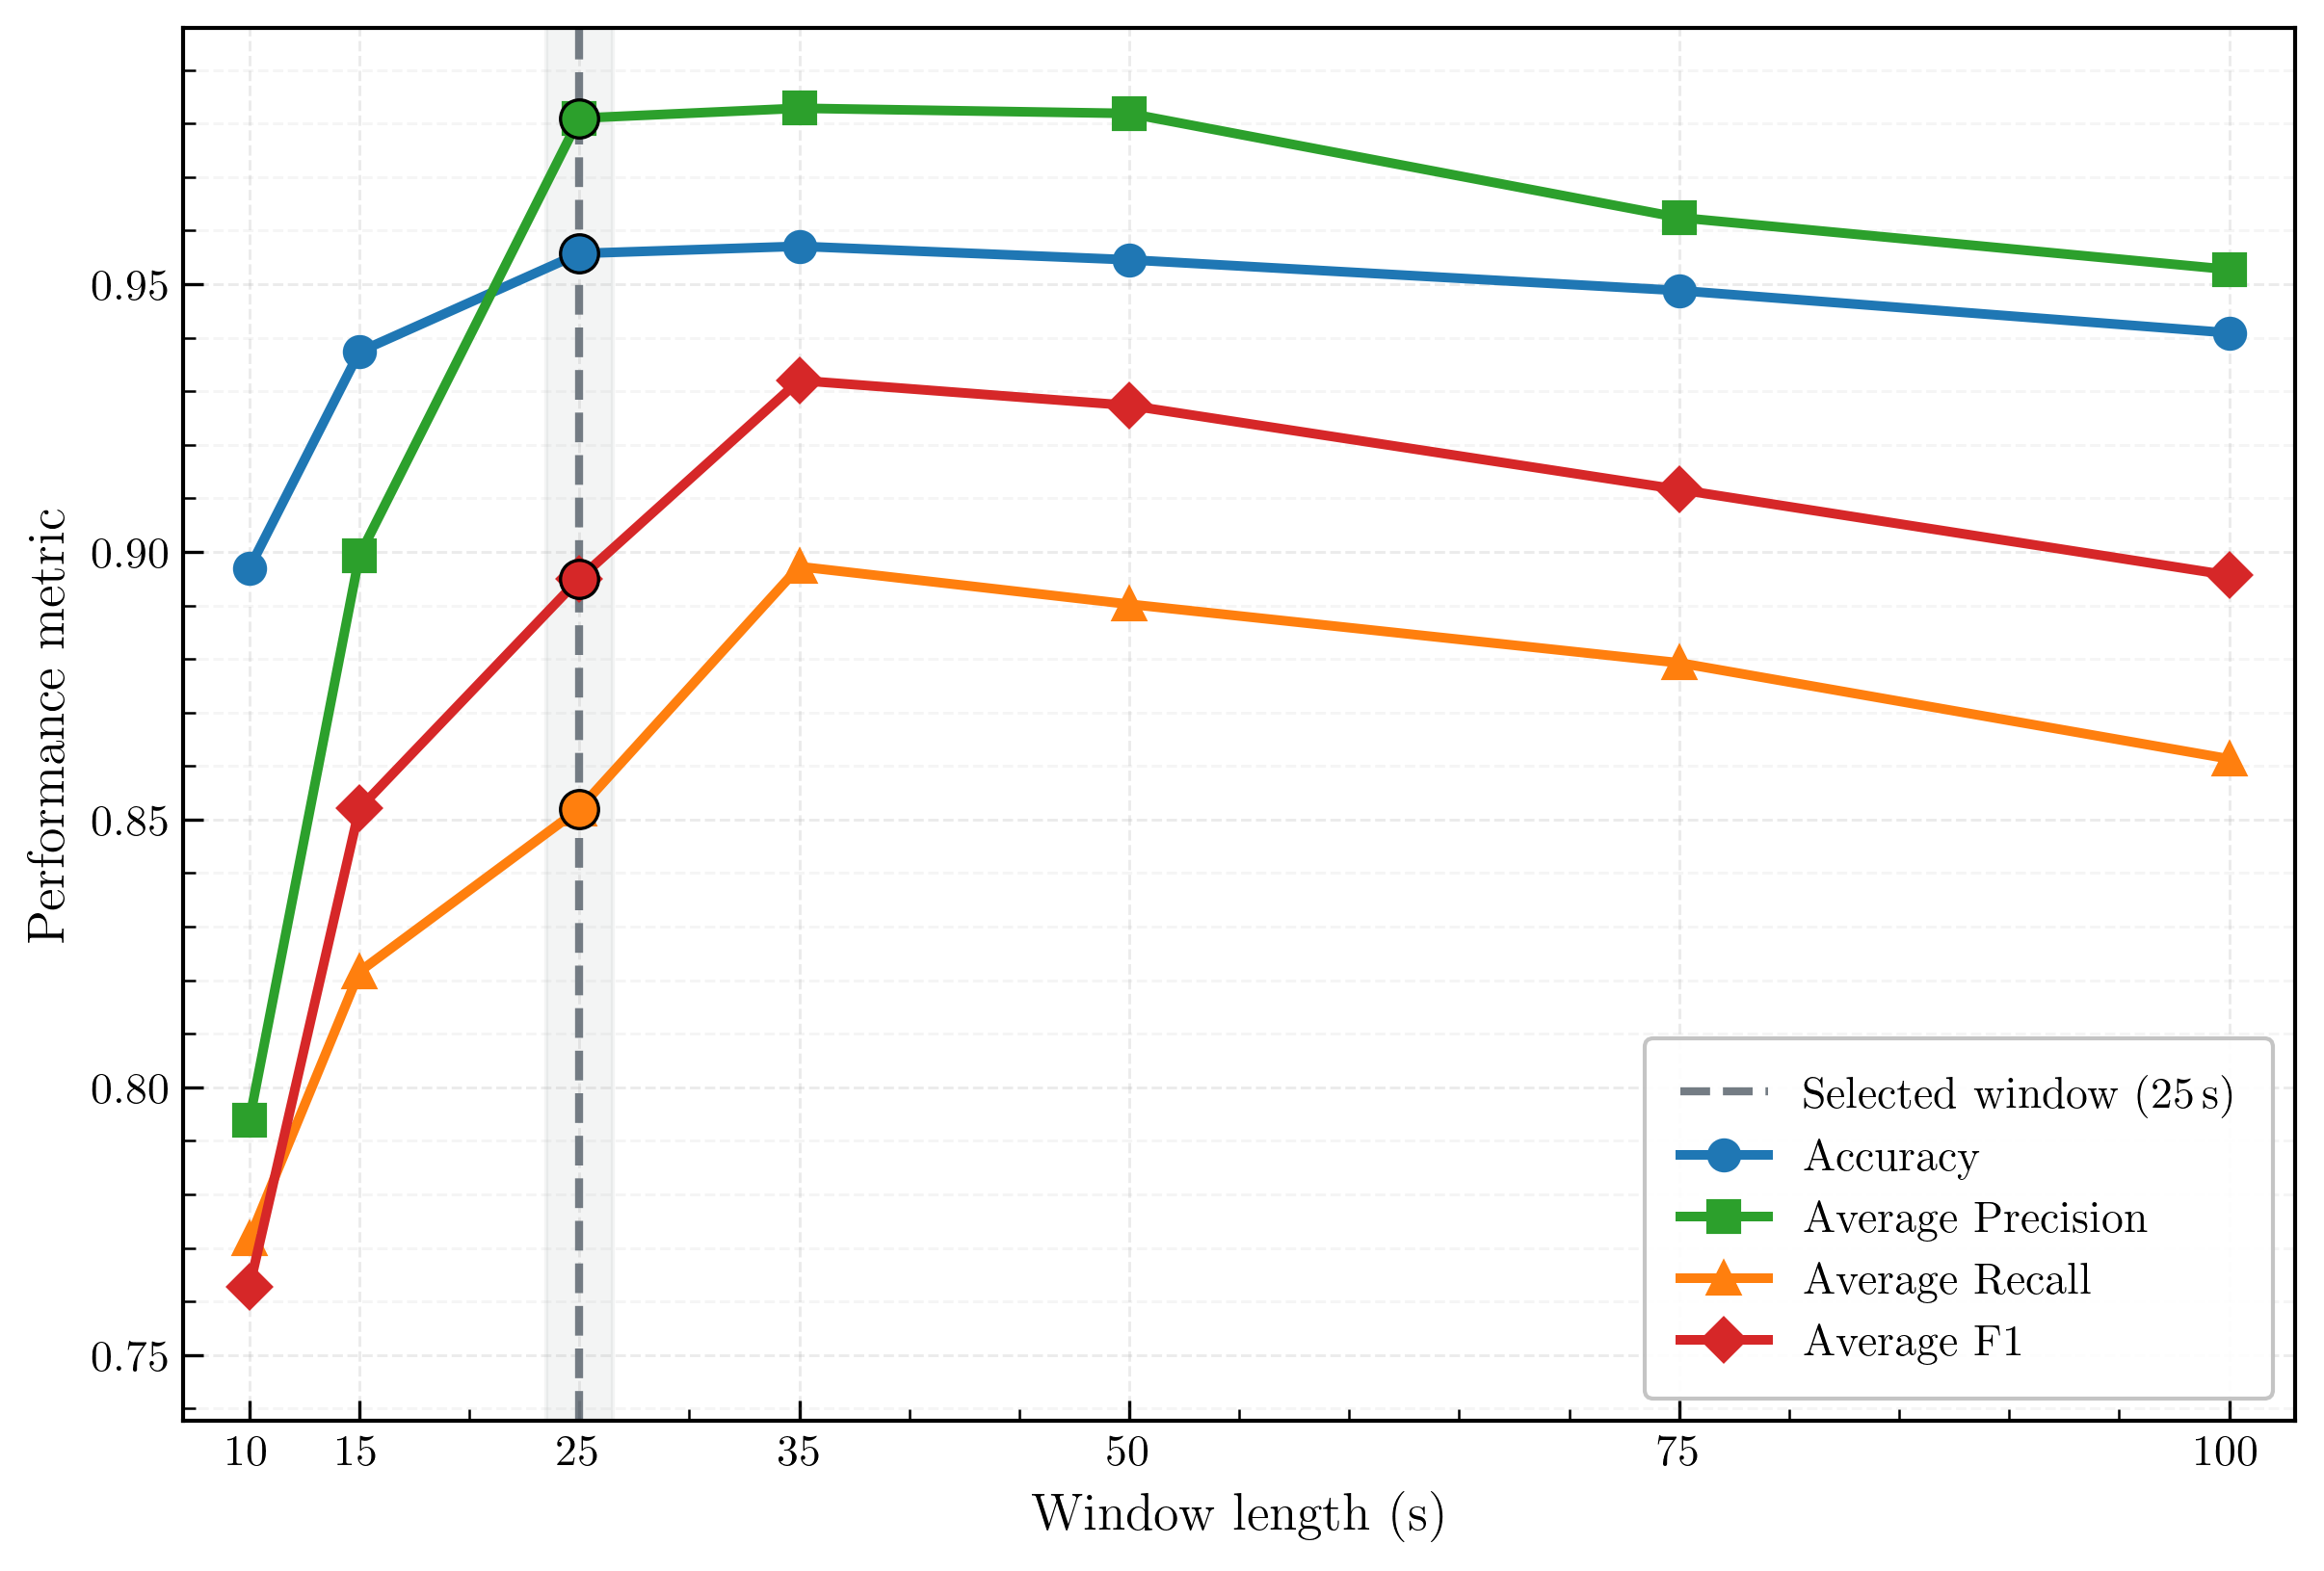

In [ ]:
# Aesthetic sensitivity-analysis plot for window-length study
# Uses LaTeX fonts/settings and highlights the selected window (25 s)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
from pathlib import Path

# ------------------------------------------------------------
# 1) Input data
# ------------------------------------------------------------
df = pd.DataFrame({
    "Window (s)": [10, 15, 25, 35, 50, 75, 100],
    "Accuracy": [0.896959, 0.937372, 0.955732, 0.957075, 0.954545, 0.948805, 0.940909],
    "Macro Precision": [0.793826, 0.899304, 0.981, 0.982857, 0.981884, 0.962434, 0.952737],
    "Macro Recall": [0.771693, 0.821583, 0.852, 0.897250, 0.890218, 0.879270, 0.861332],
    "Macro F1": [0.762674, 0.852074, 0.895, 0.932021, 0.927343, 0.911639, 0.895622],
})

# ------------------------------------------------------------
# 2) Output folder
# ------------------------------------------------------------
output_dir = Path("results") / "window_size"
output_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 3) Global plotting style
# ------------------------------------------------------------
# Keep usetex=True when LaTeX is available on your system.
# Change it to False if you get a LaTeX-related error.
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.25,
    "lines.linewidth": 2.4,
    "lines.markersize": 7.5,
    "legend.frameon": True,
    "legend.fancybox": True,
    "legend.framealpha": 0.92,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})
plt.rcParams["text.usetex"] = True   # set to False if LaTeX is not installed
plt.rcParams["font.family"] = "serif"

# ------------------------------------------------------------
# 4) Colors chosen for clean comparison
# ------------------------------------------------------------
color_acc = "#1f77b4"   # blue
color_prec = "#2ca02c"  # green
color_rec = "#ff7f0e"   # orange
color_f1 = "#d62728"    # red
selected_color = "#6c757d"  # gray for chosen window

# ------------------------------------------------------------
# 5) Prepare data
# ------------------------------------------------------------
x = df["Window (s)"].values
acc = df["Accuracy"].values
prec = df["Macro Precision"].values
rec = df["Macro Recall"].values
f1 = df["Macro F1"].values

selected_window = 25

# Find selected-window row for annotation
sel_idx = df.index[df["Window (s)"] == selected_window][0]
sel_acc = acc[sel_idx]
sel_prec = prec[sel_idx]
sel_rec = rec[sel_idx]
sel_f1 = f1[sel_idx]

# ------------------------------------------------------------
# 6) Create figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.2, 5.6))

# Light shaded band around the chosen window for emphasis
ax.axvspan(selected_window - 1.5, selected_window + 1.5,
           color=selected_color, alpha=0.08, zorder=0)

# Dashed reference line at selected window
ax.axvline(selected_window, color=selected_color, linestyle="--",
           linewidth=2.0, alpha=0.95,
           label=rf"Selected window (${selected_window}\,\mathrm{{s}}$)")

# Main curves
ax.plot(x, acc, marker="o", color=color_acc, label="Accuracy", zorder=3)
ax.plot(x, prec, marker="s", color=color_prec, label="Average Precision", zorder=3)
ax.plot(x, rec, marker="^", color=color_rec, label="Average Recall", zorder=3)
ax.plot(x, f1, marker="D", color=color_f1, label="Average F1", zorder=4)

# ------------------------------------------------------------
# 7) Highlight the selected window on every curve
# ------------------------------------------------------------
highlight_size = 90
ax.scatter([selected_window], [sel_acc], s=highlight_size, color=color_acc,
           edgecolors="black", linewidths=0.8, zorder=5)
ax.scatter([selected_window], [sel_prec], s=highlight_size, color=color_prec,
           edgecolors="black", linewidths=0.8, zorder=5)
ax.scatter([selected_window], [sel_rec], s=highlight_size, color=color_rec,
           edgecolors="black", linewidths=0.8, zorder=5)
ax.scatter([selected_window], [sel_f1], s=highlight_size, color=color_f1,
           edgecolors="black", linewidths=0.8, zorder=5)

# ------------------------------------------------------------
# 8) Annotate the selected-window values elegantly
# ------------------------------------------------------------

# ------------------------------------------------------------
# 9) Axes formatting
# ------------------------------------------------------------
#ax.set_title(r"Sensitivity of diagnosis performance to analysis window length", pad=12)
ax.set_xlabel(r"Window length (s)")
ax.set_ylabel(r"Performance metric")

ax.set_xlim(7, 103)
ax.set_xticks(x)
ax.xaxis.set_minor_locator(MultipleLocator(5))

# Tight y-limits with a small visual margin
ymin = min(acc.min(), prec.min(), rec.min(), f1.min()) - 0.025
ymax = max(acc.max(), prec.max(), rec.max(), f1.max()) + 0.015
ax.set_ylim(ymin, ymax)

ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax.yaxis.set_minor_locator(MultipleLocator(0.01))

# Grid
ax.grid(True, which="major", axis="both")
ax.grid(True, which="minor", axis="y", alpha=0.12)

# Show all spines for journal style
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(True)

# Legend
leg = ax.legend(loc="lower right", ncol=1, borderpad=0.8)
leg.get_frame().set_edgecolor("0.75")

# ------------------------------------------------------------
# 10) Optional caption-like note inside the figure
# ------------------------------------------------------------


plt.tight_layout()

# ------------------------------------------------------------
# 11) Save outputs
# ------------------------------------------------------------
fig.savefig(output_dir / "window_sensitivity_metrics_aesthetic.png", dpi=400, bbox_inches="tight")
fig.savefig(output_dir / "window_sensitivity_metrics_aesthetic.pdf", bbox_inches="tight")
fig.savefig(output_dir / "window_sensitivity_metrics_aesthetic.eps", bbox_inches="tight")

plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


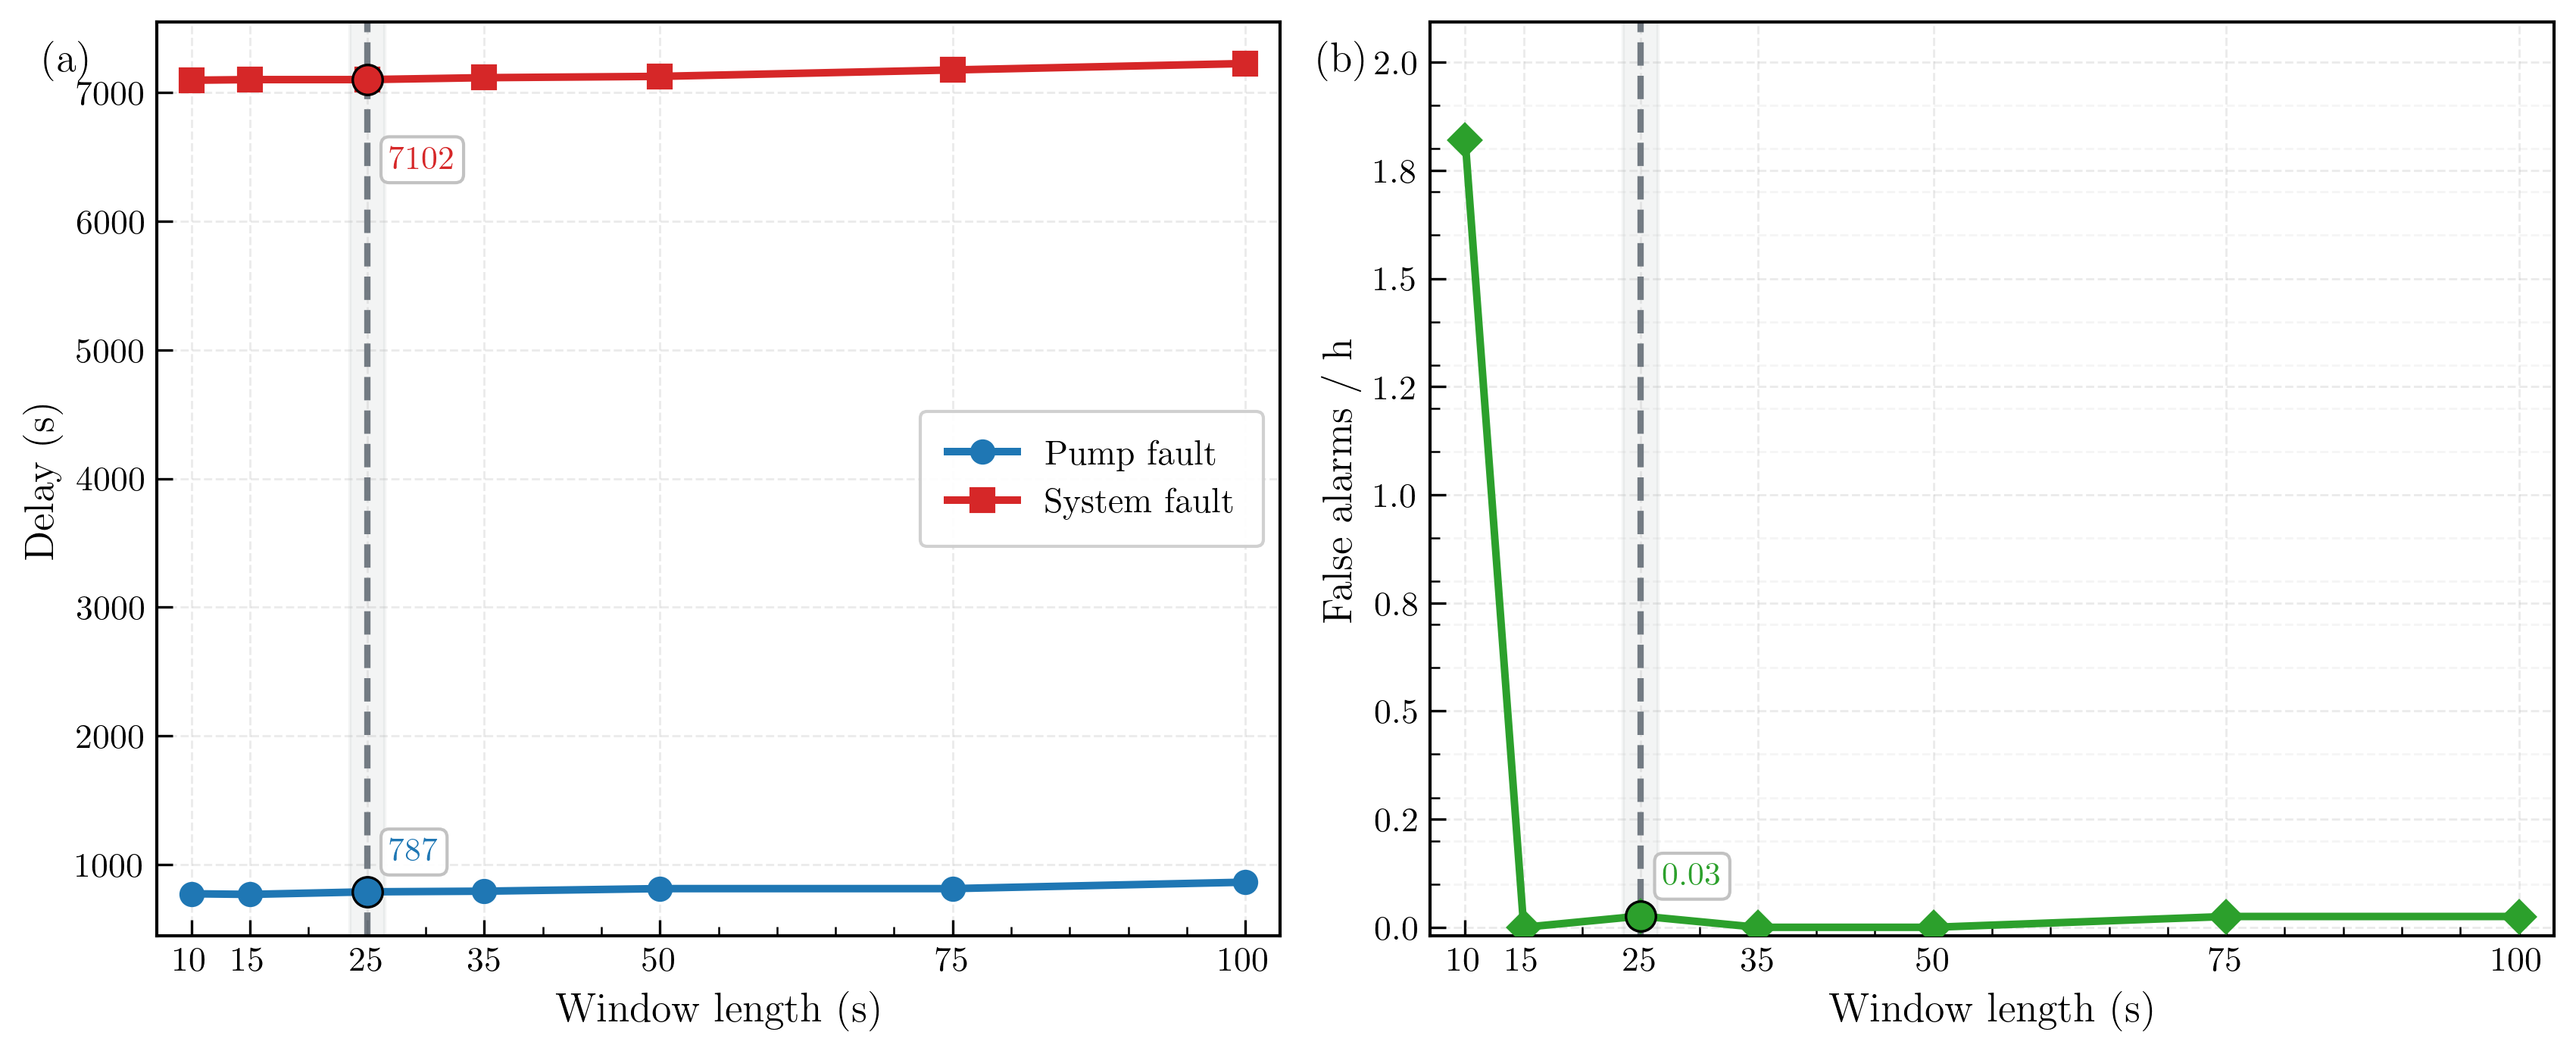

In [ ]:
# Aesthetic two-panel plot:
#   Left  : detection delays vs window length
#   Right : smoothed false alarms vs window length
# Journal-style with LaTeX fonts and selected-window dashed line
# ============================================================

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path

# ------------------------------------------------------------
# 1) Data
#    Replace these values with the exact final numbers if needed.
# ------------------------------------------------------------
df = pd.DataFrame({
    "Window (s)": [10, 15, 25, 35, 50, 75, 100],
    "Pump fault delay (raw)":   [772, 767, 787, 792, 812, 812, 862],
    "System fault delay (raw)": [7097, 7102, 7102, 7117, 7127, 7177, 7227],
    "False alarms / h (smoothed)": [1.82, 0.00, 0.026, 0.00, 0.00, 0.025, 0.025],
})

selected_window = 25

# ------------------------------------------------------------
# 2) Output folder
# ------------------------------------------------------------
output_dir = Path("results") / "window_size"
output_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 3) Global journal-style settings
# ------------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.25,
    "lines.linewidth": 2.4,
    "lines.markersize": 7.0,
    "legend.frameon": True,
    "legend.fancybox": True,
    "legend.framealpha": 0.92,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})
plt.rcParams["text.usetex"] = True   # set False if LaTeX is not installed
plt.rcParams["font.family"] = "serif"

# ------------------------------------------------------------
# 4) Colors
# ------------------------------------------------------------
color_pump = "#1f77b4"     # blue
color_system = "#d62728"   # red
color_false = "#2ca02c"    # green
selected_color = "#6c757d" # gray

# ------------------------------------------------------------
# 5) Arrays
# ------------------------------------------------------------
x = df["Window (s)"].values
pump_delay = df["Pump fault delay (raw)"].values
system_delay = df["System fault delay (raw)"].values
false_alarm_smoothed = df["False alarms / h (smoothed)"].values

# Selected window values
sel_idx = df.index[df["Window (s)"] == selected_window][0]
sel_pump = pump_delay[sel_idx]
sel_system = system_delay[sel_idx]
sel_false = false_alarm_smoothed[sel_idx]

# ------------------------------------------------------------
# 6) Figure with one row and two columns
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
ax1, ax2 = axes


# Panel labels
panel_kw = dict(fontsize=13, fontweight="bold", va="top", ha="left")
ax1.text(-0.1, 0.98, r"(a)", transform=ax1.transAxes, **panel_kw)
ax2.text(-0.1, 0.98, r"(b)", transform=ax2.transAxes, **panel_kw)
# ============================================================
# Left panel: delays
# ============================================================
ax1.axvspan(selected_window - 1.5, selected_window + 1.5,
            color=selected_color, alpha=0.08, zorder=0)
ax1.axvline(selected_window, color=selected_color, linestyle="--",
            linewidth=2.0, alpha=0.95)

ax1.plot(x, pump_delay, marker="o", color=color_pump,
         label="Pump fault", zorder=3)
ax1.plot(x, system_delay, marker="s", color=color_system,
         label="System fault", zorder=3)

# highlight chosen window
ax1.scatter([selected_window], [sel_pump], s=90, color=color_pump,
            edgecolors="black", linewidths=0.8, zorder=5)
ax1.scatter([selected_window], [sel_system], s=90, color=color_system,
            edgecolors="black", linewidths=0.8, zorder=5)

# annotations
bbox_kw = dict(boxstyle="round,pad=0.25", fc="white", ec="0.75", alpha=0.95)

ax1.annotate(rf"${int(sel_pump)}$",
             xy=(selected_window, sel_pump),
             xytext=(7, 10), textcoords="offset points",
             color=color_pump, fontsize=10.5, bbox=bbox_kw)

ax1.annotate(rf"${int(sel_system)}$",
             xy=(selected_window, sel_system),
             xytext=(7, -28), textcoords="offset points",
             color=color_system, fontsize=10.5, bbox=bbox_kw)

ax1.set_xlabel(r"Window length (s)")
ax1.set_ylabel(r"Delay (s)")
ax1.set_xlim(7, 103)
ax1.set_xticks(x)
ax1.xaxis.set_minor_locator(MultipleLocator(5))
ax1.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
ax1.grid(True, which="major", axis="both")
ax1.grid(True, which="minor", axis="y", alpha=0.12)
ax1.legend(loc="right", borderpad=0.8)

for spine in ["top", "right", "left", "bottom"]:
    ax1.spines[spine].set_visible(True)

# ============================================================
# Right panel: false alarms (smoothed only, no legend)
# ============================================================
ax2.axvspan(selected_window - 1.5, selected_window + 1.5,
            color=selected_color, alpha=0.08, zorder=0)
ax2.axvline(selected_window, color=selected_color, linestyle="--",
            linewidth=2.0, alpha=0.95)

ax2.plot(x, false_alarm_smoothed, marker="D", color=color_false, zorder=3)

# highlight chosen window
ax2.scatter([selected_window], [sel_false], s=90, color=color_false,
            edgecolors="black", linewidths=0.8, zorder=5)

# annotate chosen point
false_label = f"{sel_false:.2f}"
ax2.annotate(rf"${false_label}$",
             xy=(selected_window, sel_false),
             xytext=(7, 10), textcoords="offset points",
             color=color_false, fontsize=10.5, bbox=bbox_kw)

ax2.set_xlabel(r"Window length (s)")
ax2.set_ylabel(r"False alarms / h")
ax2.set_xlim(7, 103)
ax2.set_xticks(x)
ax2.xaxis.set_minor_locator(MultipleLocator(5))

# Nice y-limits for low false-alarm range
ymax_false = max(false_alarm_smoothed.max() * 1.15, 0.10)
ax2.set_ylim(-0.02, ymax_false)
ax2.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
ax2.yaxis.set_minor_locator(MultipleLocator(0.1))

ax2.grid(True, which="major", axis="both")
ax2.grid(True, which="minor", axis="y", alpha=0.12)

for spine in ["top", "right", "left", "bottom"]:
    ax2.spines[spine].set_visible(True)


plt.tight_layout()

# ------------------------------------------------------------
# 8) Save outputs
# ------------------------------------------------------------
fig.savefig(output_dir / "window_sensitivity_delay_falsealarm_two_panel.png",
            dpi=400, bbox_inches="tight")
fig.savefig(output_dir / "window_sensitivity_delay_falsealarm_two_panel.pdf",
            bbox_inches="tight")
fig.savefig(output_dir / "window_sensitivity_delay_falsealarm_two_panel.eps",
            bbox_inches="tight")

plt.show()